In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
df = pd.read_csv('../data/CORCCACBS.csv')






a = df.groupby(df['date'])['value'].mean().round(2)#.reset_index()
b = pd.Series(df['date'].unique()).str[:7]

df= pd.DataFrame({
    'date':b,
    'value':a.values
})

df = df.set_index('date')
print(df.head())


         value
date          
1985-01   1.95
1985-04   2.31
1985-07   2.68
1985-10   2.93
1986-01   3.18


no time filtering

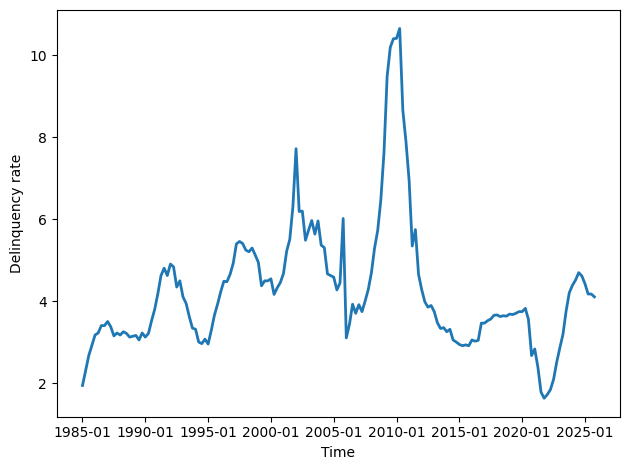

In [3]:
plt.plot(df, linewidth=2.0)
plt.ylabel('Delinquency rate')


plt.xticks(df.index[::20])

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [4]:
print(df.head())

         value
date          
1985-01   1.95
1985-04   2.31
1985-07   2.68
1985-10   2.93
1986-01   3.18


In [10]:
df = df['2011-12':'2025-10']


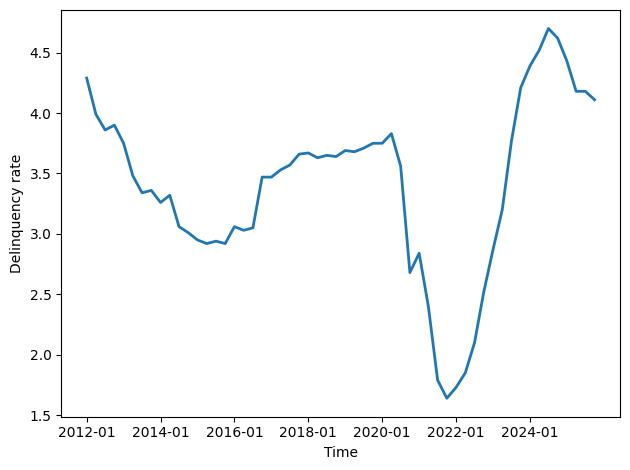

In [11]:
plt.plot(df, linewidth=2.0)
plt.ylabel('Delinquency rate')
plt.xlabel('Time')
plt.xticks(df.index[::8])

plt.tight_layout()
plt.show()

Beginning of 2022, most travel restrictions were lifted, will we see something like this soon? (travel restrictions?) dont think so not like we had in covid... do we think covid was the reason behind these drops? I personally think so but maybe it was something else 

data is definitely non-stationary


lets try a diff 

In [12]:
df_diff = df.diff(1)
print(df_diff.head(10))

         value
date          
2012-01    NaN
2012-04  -0.30
2012-07  -0.13
2012-10   0.04
2013-01  -0.15
2013-04  -0.27
2013-07  -0.14
2013-10   0.02
2014-01  -0.10
2014-04   0.06


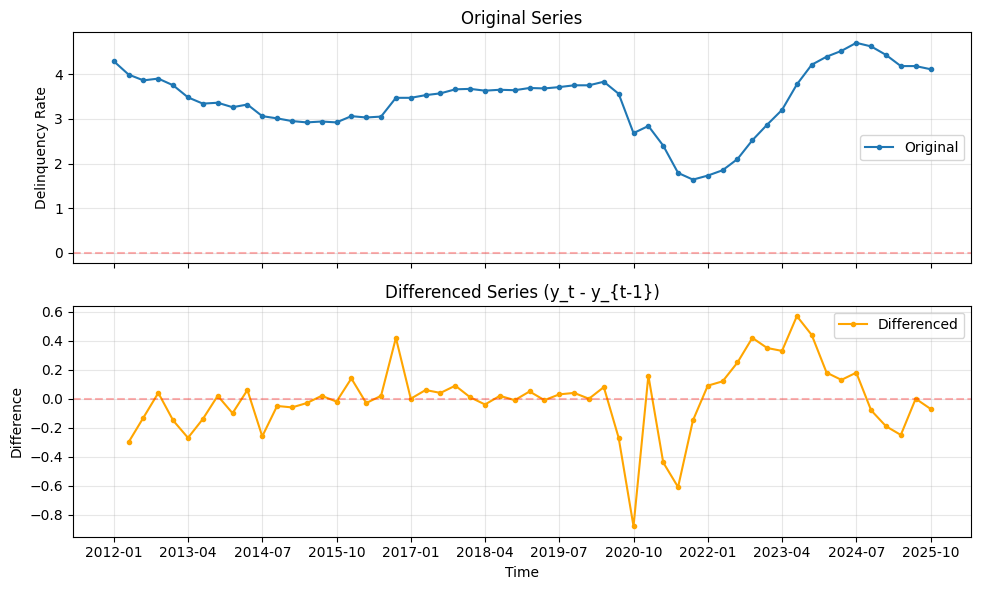

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Original series
ax1.plot(df, marker='.', linewidth=1.5, label='Original')
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.3)
ax1.set_ylabel('Delinquency Rate')
ax1.set_title('Original Series')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Differenced series
ax2.plot(df_diff, marker='.', linewidth=1.5, color='orange', label='Differenced')
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.3)
ax2.set_ylabel('Difference')
ax2.set_xlabel('Time')
ax2.set_title('Differenced Series (y_t - y_{t-1})')
ax2.legend()
plt.xticks(df.index[::5])

ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# These dont make sense just yet..... we need to forecast first
print(f'Mean absolute Error of') 
print(f'Mean absolute percentage Error:% ')


Mean absolute Error of 16.2 points 
Mean absolute percentage Error: 5.5% 


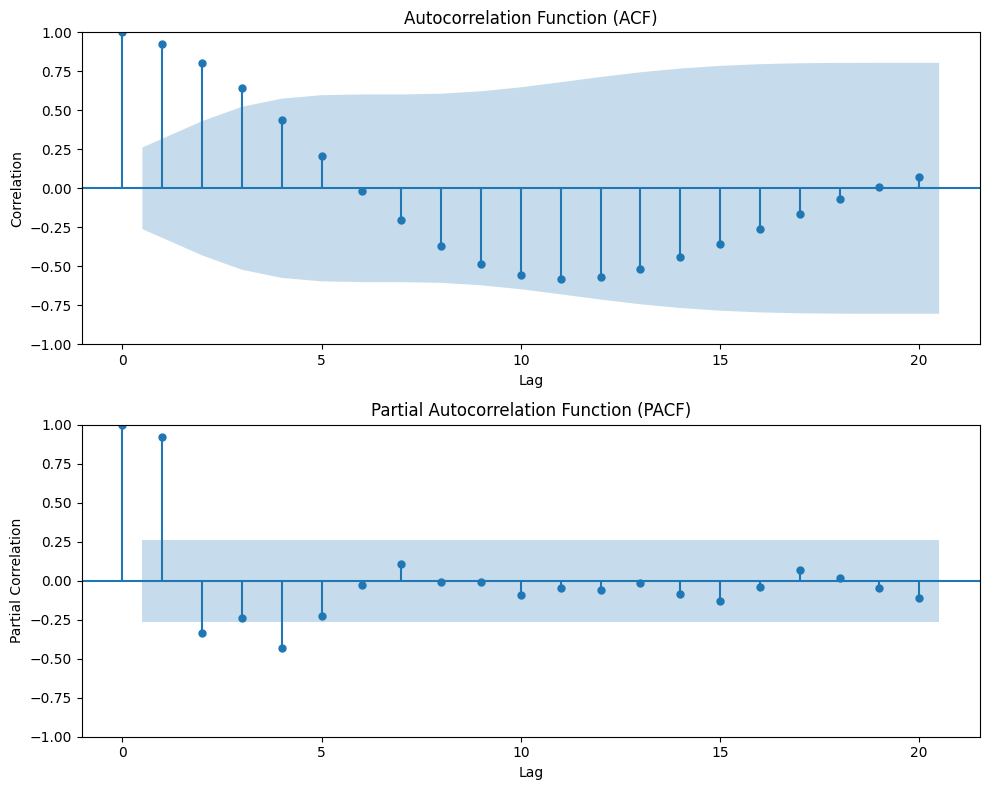

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(10,8))


# ACF plot
plot_acf(df,lags=20,ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation')

# PACF plot
plot_pacf(df, lags=20, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Partial Correlation')

plt.tight_layout()
plt.show()